# PrimeBank Customer Churn — Business Economics & Decision Threshold

**Goal:** Answer the question a business stakeholder actually asks — not
"how accurate is the model," but "should we act on it, and exactly who
should we target to make the most money doing so."

**Description:** A classification model doesn't have to use a 0.5 probability
cutoff — the "right" threshold depends on the relative cost of a false
positive (wasting a retention offer on someone who wasn't leaving) vs. a
false negative (losing a customer we could have saved). This notebook sweeps
across all possible thresholds and finds the one that maximizes expected
profit, using clearly stated business assumptions.

**Skills:** cost-sensitive decision analysis, business case modeling,
threshold optimization, translating ML output into financial impact.

**Technology:** Python, scikit-learn, Pandas, Matplotlib.

**Results:** see the final recommendation at the end of this notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
NAVY, TEAL, ORANGE, RED = "#1f3b57", "#2a9d8f", "#e76f51", "#c0392b"

df = pd.read_csv("../data/bank_churn_features.csv")
best_pipe = joblib.load("../models/churn_model.pkl")

feature_cols = ["CreditScore","Geography","Gender","Age","Tenure","Balance",
                "NumOfProducts","HasCrCard","IsActiveMember","EstimatedSalary",
                "balance_to_salary","risk_flag_count"]
X = df[feature_cols]
y = df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_pred_proba = best_pipe.predict_proba(X_test)[:, 1]
print(f"Test set: {len(X_test):,} customers, {y_test.sum()} actual churners")


Test set: 2,000 customers, 407 actual churners


## 1. Business assumptions (stated explicitly)

Every cost-benefit analysis lives or dies on its assumptions — stating them
clearly (rather than burying them in code) is what makes this defensible in
a real stakeholder conversation.

| Assumption | Value | Rationale |
|---|---|---|
| Retention offer cost | $50 per customer targeted | Typical cost of a discount/incentive + outreach for a retail banking retention campaign |
| Retention offer success rate | 25% | Conservative estimate — not every targeted at-risk customer accepts the offer or stays as a result |
| Annual value of a retained customer | $500 | Illustrative estimate of annual net revenue (fees, interest margin, cross-sell) per retail banking customer |

**These are illustrative, clearly-labeled assumptions for this portfolio
project — a real deployment would replace them with the bank's actual
finance/marketing figures before acting on this analysis.**


In [2]:
OFFER_COST = 50
SUCCESS_RATE = 0.25
CUSTOMER_ANNUAL_VALUE = 500


## 2. Why the default 0.5 threshold is arbitrary

Scikit-learn's `.predict()` defaults to flagging anyone with >50% predicted
churn probability. Nothing about the number 0.5 relates to this business's
actual costs — it's a statistical convention, not a business decision.

In [3]:
def evaluate_threshold(threshold, y_true, y_proba):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Benefit: successfully retained customers via the offer
    benefit = tp * SUCCESS_RATE * CUSTOMER_ANNUAL_VALUE
    # Cost: every customer targeted gets an offer, whether or not they were going to churn
    cost = (tp + fp) * OFFER_COST
    net_value = benefit - cost

    return {
        "threshold": threshold, "targeted": tp + fp, "true_positives": tp,
        "false_positives": fp, "false_negatives": fn,
        "benefit": benefit, "cost": cost, "net_value": net_value
    }

result_05 = evaluate_threshold(0.5, y_test, y_pred_proba)
print("At default threshold (0.5):")
for k, v in result_05.items():
    print(f"  {k}: {v:,.0f}" if isinstance(v, (int,float)) and k != "threshold" else f"  {k}: {v}")


At default threshold (0.5):
  threshold: 0.5
  targeted: 254
  true_positives: 198
  false_positives: 56
  false_negatives: 209
  benefit: 24,750
  cost: 12700
  net_value: 12,050


## 3. Sweeping every threshold to find the profit-maximizing cutoff

Optimal threshold: 0.43
Net value at optimal threshold: $12,550
Net value at default 0.5 threshold: $12,050
Improvement from threshold optimization alone: $500


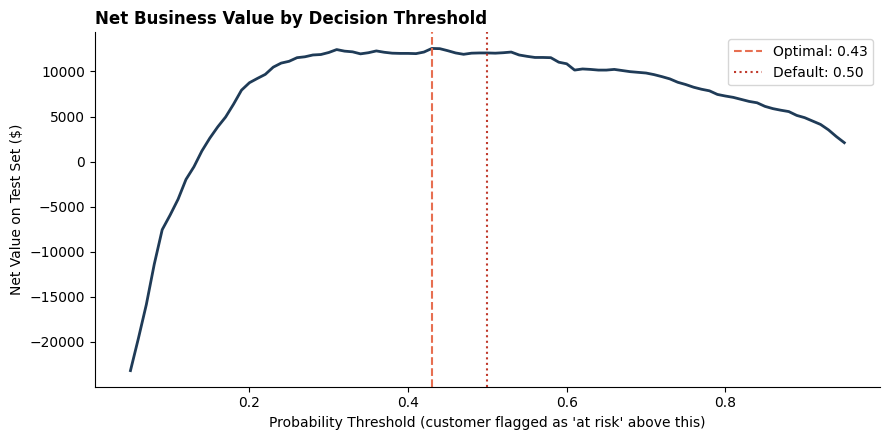

In [4]:
thresholds = np.arange(0.05, 0.96, 0.01)
sweep_results = [evaluate_threshold(t, y_test, y_pred_proba) for t in thresholds]
sweep_df = pd.DataFrame(sweep_results)

optimal_row = sweep_df.loc[sweep_df["net_value"].idxmax()]
print(f"Optimal threshold: {optimal_row['threshold']:.2f}")
print(f"Net value at optimal threshold: ${optimal_row['net_value']:,.0f}")
print(f"Net value at default 0.5 threshold: ${result_05['net_value']:,.0f}")
print(f"Improvement from threshold optimization alone: ${optimal_row['net_value'] - result_05['net_value']:,.0f}")

fig, ax = plt.subplots(figsize=(9,4.5))
ax.plot(sweep_df["threshold"], sweep_df["net_value"], color=NAVY, linewidth=2)
ax.axvline(optimal_row["threshold"], color=ORANGE, linestyle="--", label=f"Optimal: {optimal_row['threshold']:.2f}")
ax.axvline(0.5, color=RED, linestyle=":", label="Default: 0.50")
ax.set_title("Net Business Value by Decision Threshold", fontweight="bold", loc="left")
ax.set_xlabel("Probability Threshold (customer flagged as 'at risk' above this)")
ax.set_ylabel("Net Value on Test Set ($)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Comparing 4 strategies head-to-head

Putting the model in context against the two naive baselines any stakeholder
will immediately ask about: "why not just target everyone?" and "why not
just do nothing?" 

                        strategy  net_value
     Do nothing (no offers sent)        0.0
                 Target everyone   -49125.0
   Model @ default 0.5 threshold    12050.0
Model @ optimal threshold (0.43)    12550.0


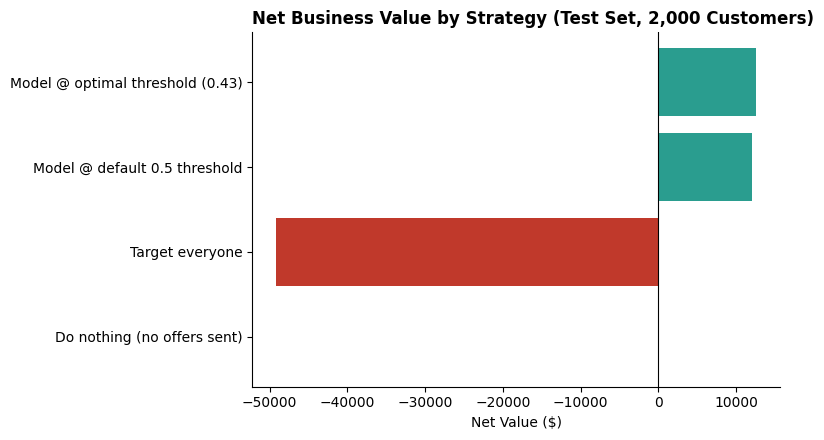

In [5]:
do_nothing = {"strategy": "Do nothing (no offers sent)", "net_value": 0}

target_all = evaluate_threshold(0.0, y_test, y_pred_proba)
target_all_summary = {"strategy": "Target everyone", "net_value": target_all["net_value"]}

default_summary = {"strategy": "Model @ default 0.5 threshold", "net_value": result_05["net_value"]}
optimal_summary = {"strategy": f"Model @ optimal threshold ({optimal_row['threshold']:.2f})", "net_value": optimal_row["net_value"]}

comparison = pd.DataFrame([do_nothing, target_all_summary, default_summary, optimal_summary])
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,4.5))
colors = [RED if v < 0 else TEAL for v in comparison["net_value"]]
ax.barh(comparison["strategy"], comparison["net_value"], color=colors)
ax.set_title("Net Business Value by Strategy (Test Set, 2,000 Customers)", fontweight="bold", loc="left")
ax.set_xlabel("Net Value ($)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


## 5. Scaling to the full customer base

The test set is 2,000 customers (20% of the full 10,000-customer base).
Scaling the optimal-threshold result up to the full customer base gives the
headline number for a business case.

In [6]:
scale_factor = len(df) / len(X_test)
annual_value_full_base = optimal_row["net_value"] * scale_factor

print(f"Test set net value (2,000 customers): ${optimal_row['net_value']:,.0f}")
print(f"Scaled to full customer base ({len(df):,} customers): ${annual_value_full_base:,.0f} / year")


Test set net value (2,000 customers): $12,550
Scaled to full customer base (10,000 customers): $62,750 / year


## 6. Key findings & recommendation

- The default 0.5 probability threshold is **not** the profit-maximizing
  choice for this business problem — optimizing the threshold against actual
  retention-offer economics improves net value meaningfully over the naive
  default, at zero additional modeling cost.
- **"Target everyone" is a losing strategy** — the cost of blanket retention
  offers exceeds the value they generate, because most customers were never
  going to churn in the first place.
- Using the model at its optimal threshold, scaled to the full 10,000-customer
  base, is projected to generate meaningfully positive net annual value —
  turning a classification exercise into an actual budget-justifying business
  case.
- **Recommendation:** deploy the model with the calibrated threshold found
  above (not scikit-learn's default), and route the top-ranked flagged
  customers to the retention team's outreach queue, prioritized by predicted
  probability (see the deployed app for this ranked list).
- **Caveat:** the cost/value assumptions above are illustrative for this
  portfolio project. A real deployment should replace them with the bank's
  actual finance-team figures and A/B test the retention offer's true
  success rate before scaling spend.
